# PyRPL spectrum-analyzer curves &mdash; convert &amp; plot

This notebook is a thin driver around two scripts that must sit **next to this
notebook**:

* `dat_to_csv.py` &mdash; converts PyRPL `.dat` curves to CSV
* `plot_curve.py` &mdash; plots / overlays / merges the CSVs

All the real work lives in those files; the notebook just imports their
functions and calls them. PyRPL saves **one channel per file**, so the GUI's
three traces (in1 = blue, in2 = green, cross = magenta) are three separate CSVs.


## 1. Setup

In [1]:
import os, sys, glob

# make sure the two scripts (in the notebook's folder) are importable
sys.path.insert(0, os.getcwd())
import dat_to_csv          # provides load_dat(), convert(), convert_dir(), main()
import plot_curve          # provides read_header(), plot_curves(), main(), ...

%matplotlib inline

# ---- edit these -----------------------------------------------------------
CURVE_DIR = os.path.expanduser("~/pyrpl_user_dir/curve")   # folder with .dat files
CSV_DIR   = os.path.join(CURVE_DIR, "csv")                 # where .csv are written
# ---------------------------------------------------------------------------

os.makedirs(CSV_DIR, exist_ok=True)
print("CURVE_DIR:", CURVE_DIR)
print(".dat files found:", len(glob.glob(os.path.join(CURVE_DIR, "*.dat"))))


CURVE_DIR: /home/ppet/pyrpl_user_dir/curve
.dat files found: 3


## 2. Convert `.dat` &rarr; `.csv`

Runs `dat_to_csv.main()`; skips conversion if the CSVs already exist (set `RECONVERT = True` to force).

In [2]:
dats = sorted(glob.glob(os.path.join(CURVE_DIR, "*.dat")),
              key=lambda p: (len(os.path.basename(p)), p))
expected = [os.path.join(CSV_DIR, os.path.splitext(os.path.basename(p))[0] + ".csv")
            for p in dats]

if not all(os.path.exists(c) for c in expected):
    dat_to_csv.convert_dir(CURVE_DIR, CSV_DIR)
else:
    print("All CSVs already present in", CSV_DIR, "(skipping; set RECONVERT=True to redo)")

csv_paths = sorted(glob.glob(os.path.join(CSV_DIR, "*.csv")),
                   key=lambda p: (len(os.path.basename(p)), p))
print("CSV files:", [os.path.basename(p) for p in csv_paths])


All CSVs already present in /home/ppet/pyrpl_user_dir/curve/csv (skipping; set RECONVERT=True to redo)
CSV files: ['1.csv', '2.csv', '3.csv']


## 3. Inspect channel names

Uses `plot_curve.read_header` to show each file's `# name:` so you can pick the in1 / in2 / cross trio.

In [3]:
for p in csv_paths:
    h = plot_curve.read_header(p)
    print(f"{os.path.basename(p):10s}  name={h.get('name', h.get('curve_name', '?'))}")


1.csv       name=spectrumanalyzer curve ch1
2.csv       name=spectrumanalyzer curve ch2
3.csv       name=spectrumanalyzer curve cross


## 4. Plot a chosen set of channels

Set `FILES` to the CSVs you want to overlay (filenames inside `CSV_DIR`).

plotting: ['1.csv', '2.csv', '3.csv']


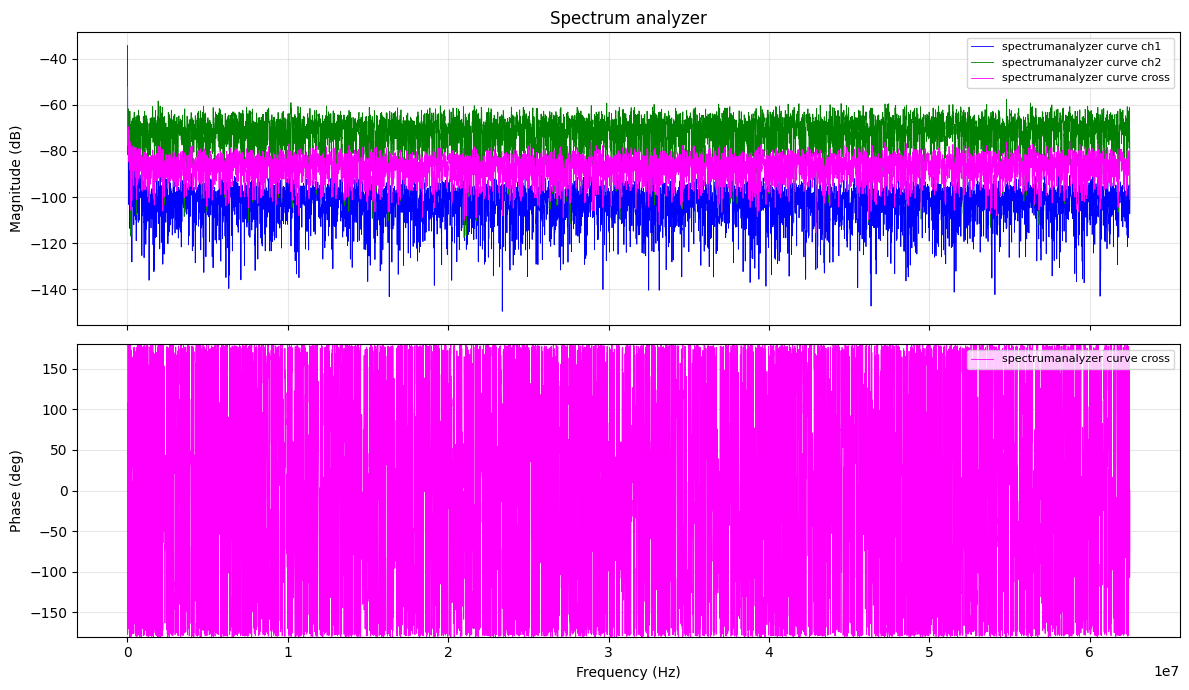

In [4]:
FILES = [os.path.basename(p) for p in csv_paths[:3]]   # edit to your trio
paths = [os.path.join(CSV_DIR, f) for f in FILES]
print("plotting:", FILES)
plot_curve.plot_curves(paths);

## 5. Overlay every CSV in the folder

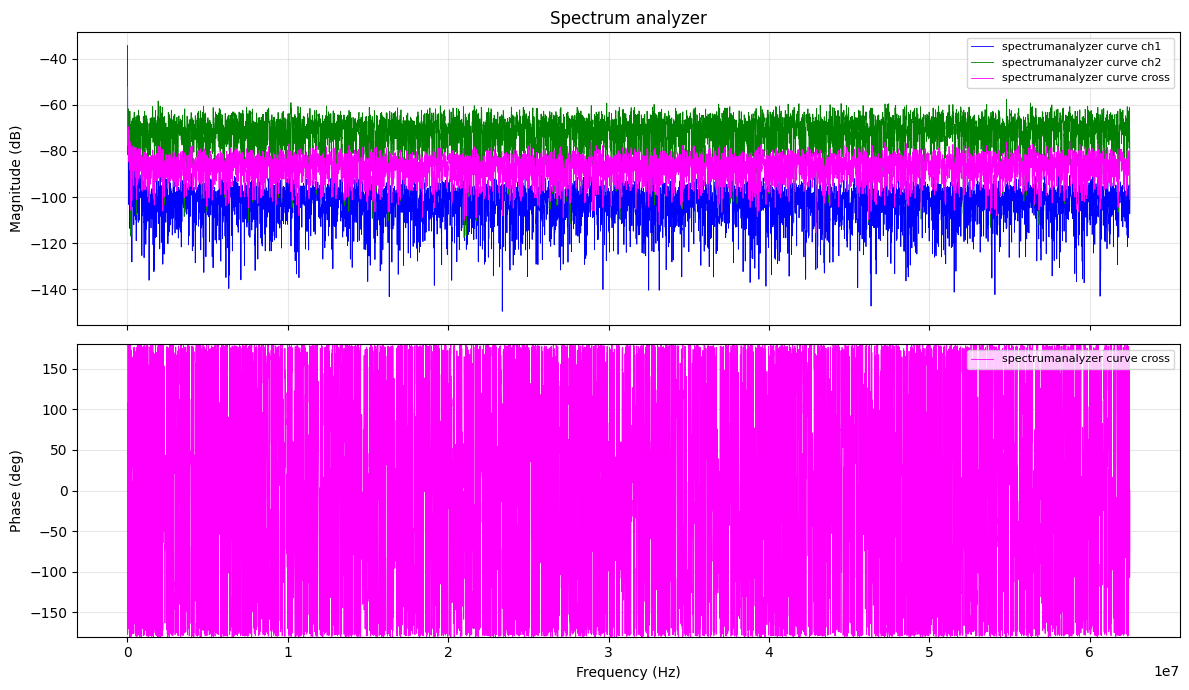

In [5]:
plot_curve.plot_curves(csv_paths);